# Drainage Polygons

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd 
import shapely

In [ ]:
shapefile = gpd.read_file("../../data/river_network/shapefile.feather")
shapefile.set_index(["__index_level_0__", "__index_level_1__", "__index_level_2__"], inplace=True)
shapefile.index.names = [None] * 3

In [3]:
shapefile

NORIOCOMP        CORIO  \
0      0 0                                          Água Azul    8641516_0   
1      0 0                                        Água Bonita  864142512_0   
2      0 0                                        Água Bonita    8962984_0   
3      0 0  Água Bonita ou das Pontinhas e Água do Capão B...   86432922_0   
         1  Água Bonita ou das Pontinhas e Água do Capão B...   86432922_0   
...                                                       ...          ...   
161531 0 0                                               None         None   
161532 0 0                                               None         None   
161533 0 0                                               None         None   
161534 0 0                                               None         None   
161535 0 0                                               None         None   

            downstream_node_id  upstream_node_id    adm2  estuary    river  \
0      0 0             75450.0          493402.0  3110.0    228.0   9478.0   
1      0 0             75974.0          494325.0  2954.0    228.0   9551.0   
2      0 0             67065.0          485868.0  1559.0    228.0  12434.0   
3      0 0            153605.0          498582.0  4759.0    228.0   9153.0   
         1            153606.0          153605.0  4759.0    228.0   9153.0   
...                        ...               ...     ...      ...      ...   
161531 0 0                 NaN          487842.0     NaN   1023.0      0.0   
161532 0 0             68579.0          486433.0     NaN   1024.0      0.0   
161533 0 0             68579.0          486793.0     NaN   1024.0      1.0   
161534 0 0             67656.0           67491.0     NaN     60.0     28.0   
161535 0 0                 NaN           68579.0     NaN   1024.0      0.0   

            segment  subsegment  \
0      0 0      0.0         0.0   
1      0 0      0.0         0.0   
2      0 0      0.0         0.0   
3      0 0      2.0         0.0   
         1      1.0         0.0   
...             ...         ...   
161531 0 0      0.0         0.0   
161532 0 0      1.0         0.0   
161533 0 0      0.0         0.0   
161534 0 0      0.0         0.0   
161535 0 0      0.0         0.0   

                                                     geometry  
0      0 0  LINESTRING (4010130.381 7424922.032, 4011257.1...  
1      0 0  LINESTRING (4037777.378 7384298.361, 4037034.2...  
2      0 0  LINESTRING (3804922.764 8019931.35, 3804511.20...  
3      0 0  LINESTRING (4176882.178 7440871.707, 4175687.8...  
         1  LINESTRING (4170252.538 7442847.873, 4170252.1...  
...                                                       ...  
161531 0 0  LINESTRING (3849965.585 10605057.641, 3850608....  
161532 0 0  LINESTRING (3818121.855 10606360.696, 3818074....  
161533 0 0  LINESTRING (3826386.147 10608748.764, 3826293....  
161534 0 0  LINESTRING (3797879.886 10615132.38, 3797842.7...  
161535 0 0  LINESTRING (3822757.94 10616623.77, 3822687.10...  

[542107 rows x 10 columns]

In [5]:
topology = gpd.read_file("../../data/river_network/topology.feather")

In [6]:
topology.query("confluence").index

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       123130, 123131, 123132, 123133, 123134, 123135, 123136, 123137, 123138,
       123139],
      dtype='int64', length=123140)

In [11]:
shapefile[shapefile.downstream_node_id.isin(topology.query("confluence").index)].groupby("downstream_node_id").size().value_counts()

2    121669
1       984
Name: count, dtype: int64

In [20]:
topology

,estuary,confluence,source,border,geometry
0,False,True,False,False,POINT (943106.381 9375682.602)
1,False,True,False,False,POINT (943570.02 9421013.29)
2,False,True,False,False,POINT (943570.028 9424712.398)
3,False,True,False,False,POINT (944497.155 9436270.843)
4,False,True,False,False,POINT (944960.677 9420088.477)
...,...,...,...,...,...
543128,True,False,True,False,POINT (5912102.639 9198545.545)
543129,True,False,True,False,POINT (5912366.669 9202259.251)
543130,True,False,True,False,POINT (5912418.175 9182831.387)
543131,True,False,True,False,POINT (5912571.568 9193833.564)


In [8]:
drainage_polygons = gpd.read_file("../../data/drainage/extracted_drainage_polygons.feather")

In [12]:
drainage_polygons_valid = drainage_polygons[drainage_polygons.geometry.is_valid]
del drainage_polygons

In [24]:
drainage_polygons_filtered = drainage_polygons_valid[~drainage_polygons_valid.geometry.is_empty]

In [48]:
drainage_polygons_filtered.loc[(drainage_polygons_filtered.count_geometries() > 1),"geometry"] = drainage_polygons_filtered.loc[(drainage_polygons_filtered.count_geometries() > 1),"geometry"].apply(
    lambda x: x.geoms[np.argmax([x.area for x in x.geoms])]
)

In [65]:
drainage_polygons_filtered = drainage_polygons_filtered.loc[drainage_polygons_filtered.geometry.apply(lambda x: isinstance(x, shapely.Polygon)),:]

<Axes: >

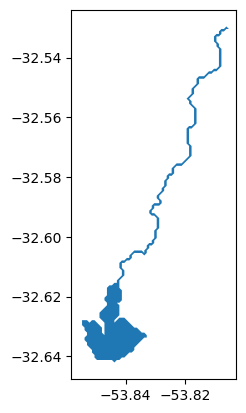

In [ ]:
drainage_polygons_filtered.iloc[[-1]].plot()

In [57]:
drainage_polygons_filtered_simplified = drainage_polygons_filtered.copy()
drainage_polygons_filtered_simplified.loc[:,"geometry"] = drainage_polygons_filtered_simplified.simplify(.01, False)

<Axes: >

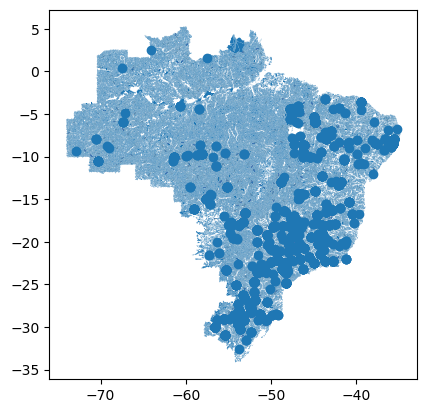

In [59]:
drainage_polygons_filtered_simplified.plot()

In [ ]:
gadm_brazil = gpd.read_file("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/gadm/gadm41_BRA.gpkg", layer="ADM_ADM_0")
drainage_polygons_filtered.area.sum() / gadm_brazil.area

/scratch/ipykernel_3775122/1541137137.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  drainage_polygons_filtered.area.sum() / gadm_brazil.area


0    0.863239
dtype: float64

In [ ]:
drainage_polygons_filtered.to_feather("/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/drainage/extracted_drainage_polygons_filtered.feather")

Coverage is good enough

---

# Extraction

In [174]:
import os
from tqdm.notebook import tqdm
# tabular
import numpy as np
import pandas as pd
import geopandas as gpd 
import shapely
# raster
import xarray as xr
import rioxarray as rxr
from odc.geo.xr import ODCExtensionDa
from odc.geo.geom import Geometry

In [ ]:
# import data
drainage_polygons = gpd.read_feather("../../data/drainage/extracted_drainage_polygons_filtered.feather")
legend = pd.read_excel("../../data/land_cover/mapbiomas_legend.xlsx")

In [ ]:
# define vectorized mappers
legend_class_dict = legend.set_index("ID").Class.to_dict()
legend_subclass_dict = legend.set_index("ID").Subclass.to_dict()

legend_class_dict_mapper = np.vectorize(lambda x: legend_class_dict.get(x, np.nan))
legend_subclass_dict_mapper = np.vectorize(lambda x: legend_subclass_dict.get(x, np.nan))

def add_crs(geom, crs=4326):
    return Geometry(geom, crs)

In [ ]:
datadir = "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/land_cover/raw/lc_mapbiomas8_30/"
files = pd.Series(os.listdir(datadir)).sort_values().set_axis(files.str.extract(r"(\d{4,})").iloc[:,0].astype("int"))

In [164]:
mi = pd.MultiIndex.from_product([drainage_polygons.index.values, files.index], names=['id', 'year'])

In [165]:
out_df = pd.DataFrame(0, index = mi, columns=[0, 1, 2, 3, 4, 20, 21, 30, 31])

In [168]:
for year, file in tqdm(files.items(), total = files.shape[0], desc="Outer loop", position=0):
    lc = xr.open_rasterio(datadir + file, chunks=None)
    
    for j in tqdm(drainage_polygons.index, desc="Inner loop", position=1, leave=False):

        cropped_data = np.unique(
            lc.odc.crop(add_crs(drainage_polygons.iloc[j].geometry)),
            return_counts=True
        )

        # (values, counts)
        values, counts = cropped_data

        for mapper in (legend_class_dict_mapper, legend_subclass_dict_mapper):

            # Map values to classes
            cropped_data_classes = mapper(values)

            # Remove NaNs
            valid = ~np.isnan(cropped_data_classes)
            classes = cropped_data_classes[valid].astype(int)
            weights = counts[valid]

            # Safer aggregation
            # unique classes + inverse mapping
            uniq, inv = np.unique(classes, return_inverse=True)
            agg = np.bincount(inv, weights=weights)

            # Write to df
            out_df.loc[(j,year), uniq] = agg

Outer loop:   0%|          | 0/40 [00:00<?, ?it/s]

Inner loop:   0%|          | 0/1134414 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [178]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm
import numpy as np
import xarray as xr

def process_polygon(j, geom, lc, legend_class_dict_mapper, legend_subclass_dict_mapper):
    """Process single polygon and return results."""
    from odc.geo.xr import ODCExtensionDa
    cropped_data = np.unique(
        lc.odc.crop(add_crs(geom)),
        return_counts=True
    )
    values, counts = cropped_data
    
    all_results = []
    for mapper in (legend_class_dict_mapper, legend_subclass_dict_mapper):
        cropped_data_classes = mapper(values)
        valid = ~np.isnan(cropped_data_classes)
        classes = cropped_data_classes[valid].astype(int)
        weights = counts[valid]
        uniq, inv = np.unique(classes, return_inverse=True)
        agg = np.bincount(inv, weights=weights)
        all_results.append((uniq, agg))
    
    return j, all_results

# Main loop with parallel inner loop
for year, file in tqdm(files.items(), total=len(files), desc="Years", position=0):
    lc = rxr.open_rasterio(datadir + file, chunks=None)
    
    results = Parallel(n_jobs=-1, backend="loky")(
        delayed(process_polygon)(j, drainage_polygons.iloc[j].geometry, lc, 
                                  legend_class_dict_mapper, legend_subclass_dict_mapper)
        for j in tqdm(drainage_polygons.index, desc="Polygons", position=1, leave=False)
    )
    
    # Write results back to dataframe
    for j, mapper_results in results:
        for uniq, agg in mapper_results:
            out_df.loc[(j, year), uniq] = agg

Years:   0%|          | 0/40 [00:00<?, ?it/s]

Polygons:   0%|          | 0/1134414 [00:00<?, ?it/s]

KeyboardInterrupt: 

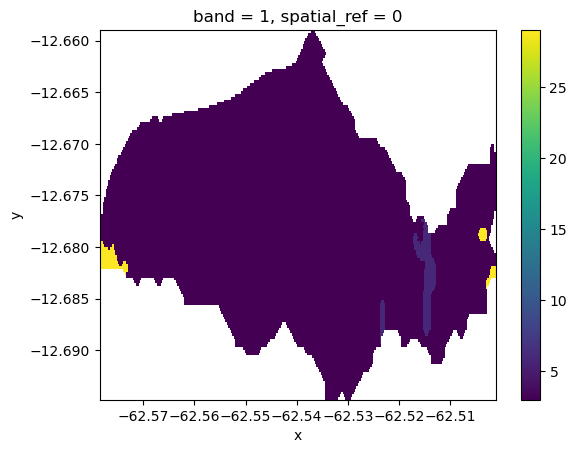

In [6]:
lc.odc.crop(add_crs(drainage_polygons.iloc[0].geometry)).squeeze().plot.imshow()

In [ ]:
drainage_polygons

In [1]:
import pandas as pd

In [5]:
pd.read_feather("../../data/land_cover/land_cover_results.feather")["0"].sum()

np.int64(214132816124)

---

In [23]:
from collections import defaultdict

def calculate_distance_from_estuary(rivers, topology, segment_length = 1000):
    """
    Calculates the distance of river segments from the nearest estuary. This function updates
    the `rivers` DataFrame by adding two new columns: `distance_from_estuary` and `segment_offset`.
    The calculation is done by tracing the river network upstream, starting from estuary points,
    to compute cumulative distances for each segment.

    Parameters:
    - rivers (pd.DataFrame): A DataFrame containing river network data. It must include columns
      for `downstream_node_id`, `upstream_node_id`, `length`, and identifying attributes for
      estuaries (e.g., 'river', 'segment', 'subsegment').
    - topology (pd.DataFrame): A DataFrame describing the topology of the network. It should
      contain Boolean columns `source` and `estuary` to identify river sources and estuaries.
    - segment_length (int, optional): The base segment length used to calculate segment offsets.
      Default value is 1000.

    Returns:
    - pd.DataFrame: The updated `rivers` DataFrame with added `distance_from_estuary` and
      `segment_offset` columns, representing the distance from the nearest estuary and the
      distance modulo the `segment_length`, respectively.

    Notes:
    - This function uses multiprocessing for calculating the distance from the estuary for each
      segment efficiently.
    - The function assumes all data are clean and correctly formatted. Missing values in the
      necessary columns may lead to failures or incorrect results.
    """
    # create a dict from end point to upstream river ids
    dict_points = defaultdict(list)
    # Iterate over pairs of corresponding tuples from both arrays
    for point, index in zip(rivers.dropna(subset = "downstream_node_id").downstream_node_id.astype(np.int32), rivers.dropna(subset = "downstream_node_id").index):
        # Append the index to the list corresponding to the point
        dict_points[point].append(index)
    # Convert defaultdict to dict
    downstream_lookup = dict(dict_points)
    # create a dict from river id to end node
    upstream_lookup = {key: value for key, value in zip(rivers.dropna(subset = "upstream_node_id").index, rivers.dropna(subset = "upstream_node_id").upstream_node_id.astype(np.int32))}
    # create a dict from river id to length
    length_lookup = {key: value for key, value in zip(rivers.dropna(subset = "upstream_node_id").index, rivers.dropna(subset = "upstream_node_id").length)}
    # create a dict to check if a point is a river source node
    end_node_lookup = {x: True for x in topology[topology.source & ~topology.estuary].index}

    # get all river ids of nodes at estuaries
    estuary_ids = rivers.query("river==0 & segment==0 & subsegment==0").index.to_list()

    # prepare data for multiprocessing
    datasets = []
    for i in range(len(estuary_ids)):
        datasets.append([{key: 0 for key in rivers[rivers.estuary == rivers.loc[estuary_ids[i]].estuary].dropna(subset = "upstream_node_id").index}, (estuary_ids[i], 0)])

    # function to calculate segment offsets
    def calculate_distance_from_estuary(dataset):
        query = [dataset[1]]
        out = dataset[0]
        while query:
            tmp = query.pop()
            out[tmp[0]] = tmp[1]
            if not end_node_lookup.get(upstream_lookup[tmp[0]], False):
                query += [(x, ((tmp[1] + length_lookup[tmp[0]]))) for x in downstream_lookup.get(upstream_lookup[tmp[0]], [])] # % 1000
        return out
    # compute segment offsets
    distance_from_estuary = [calculate_distance_from_estuary(x) for x in datasets]
    
    # write segment offsets to shapefile
    rivers["distance_from_estuary"] = np.nan
    rivers.update(pd.concat([pd.DataFrame({"distance_from_estuary": x}) for x in distance_from_estuary]))
    rivers["distance_from_estuary"] = pd.to_numeric(rivers.distance_from_estuary.round(0))
    rivers["segment_offset"] = pd.to_numeric(rivers.distance_from_estuary % segment_length)
    
    return rivers

In [24]:
test = calculate_distance_from_estuary(shapefile, topology)

In [ ]:
test.query("estuary==229").sort_values(["distance_from_estuary"])

In [34]:
test.query("estuary==229").sort_values(["river", "segment", "subsegment"])

NORIOCOMP     CORIO  downstream_node_id  \
39031 0 34  Rio da Ribeira do Iguape     794_0                 NaN   
        33  Rio da Ribeira do Iguape     794_0             89556.0   
        32  Rio da Ribeira do Iguape     794_0             89256.0   
        31  Rio da Ribeira do Iguape     794_0             89257.0   
        29  Rio da Ribeira do Iguape     794_0            302795.0   
...                              ...       ...                 ...   
8458  0 2     Córrego do Braço Preto  794142_0             89177.0   
        0     Córrego do Braço Preto  794142_0            301547.0   
38958 0 0              Rio da Momuna   79412_0             89556.0   
35493 0 0            Ribeirão Momuna   79412_1             89593.0   
41850 0 0              Rio Nhanguara  794122_0             89593.0   

            upstream_node_id    adm2  estuary  river  segment  subsegment  \
39031 0 34           89556.0  4946.0    229.0    0.0      0.0         0.0   
        33           89256.0  4946.0    229.0    0.0      1.0         0.0   
        32           89257.0  4946.0    229.0    0.0      2.0         0.0   
        31          302795.0  4946.0    229.0    0.0      3.0         0.0   
        29           89280.0  5121.0    229.0    0.0      4.0         0.0   
...                      ...     ...      ...    ...      ...         ...   
8458  0 2           301547.0  4946.0    229.0  209.0      0.0         0.0   
        0           507110.0  5121.0    229.0  209.0      1.0         0.0   
38958 0 0            89593.0  4946.0    229.0  210.0      0.0         0.0   
35493 0 0           507372.0  4946.0    229.0  210.0      1.0         0.0   
41850 0 0           507614.0  4946.0    229.0  211.0      0.0         0.0   

                                                     geometry  \
39031 0 34  LINESTRING (4479895.16 7183192.832, 4480002.08...   
        33  LINESTRING (4472844.179 7188209.957, 4472842.6...   
        32  LINESTRING (4472851.418 7188343.163, 4472844.1...   
        31  LINESTRING (4473031.988 7188719.979, 4473026.2...   
        29  LINESTRING (4473554.216 7189824.963, 4473550.5...   
...                                                       ...   
8458  0 2   LINESTRING (4470432.914 7184546.862, 4470561.9...   
        0   LINESTRING (4461303.115 7178138.865, 4461996.6...   
38958 0 0   LINESTRING (4480368.325 7180775.279, 4479731.7...   
35493 0 0   LINESTRING (4467201.75 7170302.976, 4467703.81...   
41850 0 0   LINESTRING (4472952.003 7179864.401, 4474039.2...   

            distance_from_estuary  segment_offset  
39031 0 34                    0.0             0.0  
        33                19497.0           497.0  
        32                35695.0           695.0  
        31                35829.0           829.0  
        29                36247.0           247.0  
...                           ...             ...  
8458  0 2                 40534.0           534.0  
        0                 40823.0           823.0  
38958 0 0                 19497.0           497.0  
35493 0 0                 22064.0            64.0  
41850 0 0                 22064.0            64.0  

[1430 rows x 12 columns]

<Axes: >

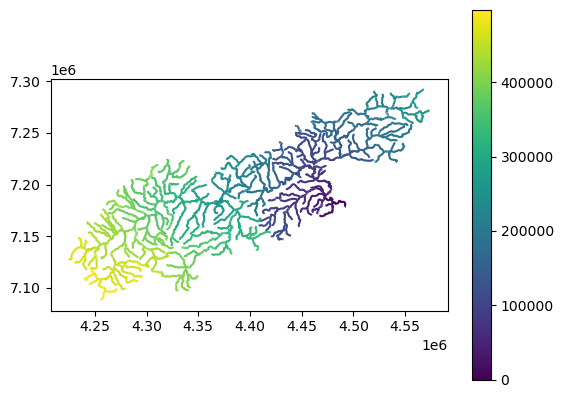

In [29]:
test.query("estuary==229").plot(column="distance_from_estuary", cmap="viridis", legend=True)

In [ ]:
# Merge distances back to edges for visualization/analysis
shapefile_with_dist = shapefile.merge(
    distances_df,
    left_on='upstream_node',
    right_on='node_id',
    how='left'
)
shapefile_with_dist.head()

---

In [1]:
import pandas as pd
import geopandas as gpd
import sys
sys.path.append("../data")
from river_network import river_network

# Load existing network
network = river_network.load_network(
    "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network/shapefile_old.parquet",
    "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network/topology.parquet",
    "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network/distance_from_estuary.parquet"
)

In [2]:
import shapely

to_fix = ((network.shapefile.downstream_node_id.isna()) & (~network.shapefile.upstream_node_id.isna()))

def worker(g):
    return network.topology.\
        query("estuary").\
            index[
                shapely.dwithin(
                    g,
                    network.topology.query("estuary").geometry,
                    1
                    ).\
                        argmax()
                ]

network.shapefile.loc[to_fix,"downstream_node_id"] = network.shapefile.loc[to_fix,"geometry"].\
    apply(worker)

In [5]:
shapefile_with_dist = network.shapefile.join(network.distance_from_estuary, how="inner")
shapefile_with_dist.head()

NORIOCOMP        CORIO  \
0 0 0                                          Água Azul    8641516_0   
1 0 0                                        Água Bonita  864142512_0   
2 0 0                                        Água Bonita    8962984_0   
3 0 0  Água Bonita ou das Pontinhas e Água do Capão B...   86432922_0   
    1  Água Bonita ou das Pontinhas e Água do Capão B...   86432922_0   

       downstream_node_id  upstream_node_id    adm2  estuary    river  \
0 0 0             75450.0          493402.0  3110.0    228.0   9478.0   
1 0 0             75974.0          494325.0  2954.0    228.0   9551.0   
2 0 0             67065.0          485868.0  1559.0    228.0  12434.0   
3 0 0            153605.0          498582.0  4759.0    228.0   9153.0   
    1            153606.0          153605.0  4759.0    228.0   9153.0   

       segment  subsegment                                           geometry  \
0 0 0      0.0         0.0  LINESTRING (4010130.381 7424922.032, 4011257.1...   
1 0 0      0.0         0.0  LINESTRING (4037777.378 7384298.361, 4037034.2...   
2 0 0      0.0         0.0  LINESTRING (3804922.764 8019931.35, 3804511.20...   
3 0 0      2.0         0.0  LINESTRING (4176882.178 7440871.707, 4175687.8...   
    1      1.0         0.0  LINESTRING (4170252.538 7442847.873, 4170252.1...   

       distance_from_estuary  segment_offset  
0 0 0              2885292.0           292.0  
1 0 0              2970404.0           404.0  
2 0 0              3992036.0            36.0  
3 0 0              3092303.0           303.0  
    1              3092302.0           302.0

In [40]:
import networkx as nx

In [166]:
nodes_distances = network.shapefile.join(network.distance_from_estuary, how="inner")
node_distance_lookup = nodes_distances.astype({"downstream_node_id": "int"}).groupby("downstream_node_id")["distance_from_estuary"].first().astype("int").to_dict()
del nodes_distances

In [31]:
shapefile_with_dist.groupby("estuary").size().sort_values().tail(50)

estuary
507.0       255
200.0       256
276.0       266
331.0       279
486.0       282
445.0       292
145.0       309
478.0       325
319.0       325
176.0       327
211.0       334
438.0       351
422.0       359
515.0       360
177.0       407
394.0       424
510.0       449
212.0       468
314.0       471
401.0       512
139.0       588
449.0       593
316.0       613
527.0       629
128.0       713
830.0       728
168.0       892
514.0      1102
143.0      1273
242.0      1322
229.0      1430
29.0       1698
321.0      1887
407.0      1948
397.0      2400
293.0      2448
236.0      2562
431.0      2951
409.0      3661
338.0      3858
349.0      4002
318.0      4341
256.0      5498
335.0      7077
386.0      7937
414.0     15764
471.0     25985
19.0      44588
228.0     92601
136.0    157308
dtype: int64

In [45]:
estuary_rivers = shapefile_with_dist.query("estuary==60")#
edges = estuary_rivers.loc[:, ["downstream_node_id", "upstream_node_id", "distance_from_estuary"]].values.tolist()
# pack
edges = [[a, b, {"idx": ix, "distance_from_estuary": c}] for ix, (a, b, c) in enumerate(edges)]

In [46]:
G = nx.DiGraph()
G.add_edges_from(edges)

In [23]:
import numpy as np
from scipy.sparse import csr_array

def original_version(G):
    out_matrix = np.zeros((len(edges), len(edges)))

    for edge in G.edges:

        upstream_nodes = nx.descendants(G, edge[0])

        for upstream_node in upstream_nodes:
            for node_edge in G.edges(upstream_node):
                out_matrix[G.edges[edge]["idx"], G.edges[node_edge]["idx"]] = G.edges[node_edge]["distance_from_estuary"] - G.edges[edge]["distance_from_estuary"]
                
    out_matrix = csr_array(out_matrix)

In [22]:
import numpy as np
from scipy.sparse import coo_array

def optimized_version(G):
    # Topological sort
    topo_order = list(nx.topological_sort(G))

    # Extract edge metadata
    edge_list = list(G.edges)
    n_edges = len(edge_list)
    edge_to_idx = {edge: G.edges[edge]["idx"] for edge in edge_list}

    # Build distance array
    edge_distances = np.empty(n_edges)
    for edge in edge_list:
        edge_distances[edge_to_idx[edge]] = G.edges[edge]["distance_from_estuary"]

    # Compute descendants efficiently
    descendants = {}
    for node in reversed(topo_order):
        desc = set()
        for successor in G.successors(node):
            desc.add(successor)
            desc.update(descendants.get(successor, set()))
        descendants[node] = desc

    # Build sparse matrix in COO format
    rows, cols, data = [], [], []

    for edge in edge_list:
        row_idx = edge_to_idx[edge]
        edge_dist = edge_distances[row_idx]
        
        for upstream_node in descendants[edge[0]]:
            for upstream_edge in G.edges(upstream_node):
                col_idx = edge_to_idx[upstream_edge]
                rows.append(row_idx)
                cols.append(col_idx)
                data.append(edge_distances[col_idx] - edge_dist)

    out_matrix = coo_array((data, (rows, cols)), shape=(n_edges, n_edges)).tocsr()


In [ ]:
def caching_version(G):
    import numpy as np
    from collections import defaultdict
    from scipy.sparse import coo_array
    import functools
    import networkx as nx
    from tqdm.notebook import tqdm

    edge_list = list(G.edges)
    E = len(edge_list)

    edge_idx = np.empty(E, dtype=int)
    edge_dist = np.empty(E, dtype=float)

    # pos is 0..E-1
    for pos, e in enumerate(edge_list):
        edge_idx[pos] = G.edges[e]["idx"]                # arbitrary labels
        edge_dist[pos] = G.edges[e]["distance_from_estuary"]

    # node -> list of *positions* into edge_list
    node_edges_pos = defaultdict(list)
    for pos, (u, v) in enumerate(edge_list):
        node_edges_pos[u].append(pos)

    # descendants per node (nodes, not edges)
    node_descendants = {u: nx.descendants(G, u) for u in G.nodes}

    # define cached function that uses positions only
    @functools.lru_cache(maxsize=None)
    def downstream_edge_positions(pos):
        src_node = edge_list[pos][0]
        result = []

        # edges from src_node itself
        for p in node_edges_pos.get(src_node, ()):
            result.append(p)

        # edges from descendant nodes
        for dn in node_descendants.get(src_node, ()):
            for p in node_edges_pos.get(dn, ()):
                result.append(p)

        return tuple(result)

    rows = []
    cols = []
    data = []

    for pos in tqdm(range(E)):
        row = edge_idx[pos]          # this is the *matrix* row label
        base_dist = edge_dist[pos]

        for up_pos in downstream_edge_positions(pos):
            col = edge_idx[up_pos]   # matrix column label
            rows.append(row)
            cols.append(col)
            data.append(edge_dist[up_pos] - base_dist)

    # shape must accommodate the max idx value, not just E
    n = int(max(edge_idx)) + 1
    out_matrix = coo_array((data, (rows, cols)), shape=(n, n)).tocsr()
    return out_matrix

In [35]:
def caching_version_queue(G):
    import numpy as np
    from collections import defaultdict, deque
    from scipy.sparse import coo_array
    import functools
    from tqdm.notebook import tqdm

    # Precompute edge list and simple arrays
    edge_list = list(G.edges)
    E = len(edge_list)

    edge_idx = np.empty(E, dtype=int)
    edge_dist = np.empty(E, dtype=float)

    # pos is 0..E-1
    for pos, e in enumerate(edge_list):
        edge_idx[pos] = G.edges[e]["idx"]                # matrix label
        edge_dist[pos] = G.edges[e]["distance_from_estuary"]

    # node -> list of positions into edge_list
    node_edges_pos = defaultdict(list)
    # adjacency: node -> list of neighbor nodes for BFS
    adj = defaultdict(list)

    for pos, (u, v) in enumerate(edge_list):
        node_edges_pos[u].append(pos)
        adj[u].append(v)

    @functools.lru_cache(maxsize=None)
    def downstream_edge_positions(pos):
        """
        Return tuple of positions (0..E-1) of all edges reachable
        from the source node of edge at position `pos`, using BFS.
        """
        src_node = edge_list[pos][0]
        result = []

        # BFS with a queue over nodes
        q = deque([src_node])
        visited = set([src_node])

        while q:
            u = q.popleft()

            # all edges out of this node
            for p in node_edges_pos.get(u, ()):
                result.append(p)

            # continue to neighbors
            for v in adj.get(u, ()):
                if v not in visited:
                    visited.add(v)
                    q.append(v)

        return tuple(result)

    rows = []
    cols = []
    data = []

    for pos in tqdm(range(E)):
        row = edge_idx[pos]
        base_dist = edge_dist[pos]

        for up_pos in downstream_edge_positions(pos):
            col = edge_idx[up_pos]
            rows.append(row)
            cols.append(col)
            data.append(edge_dist[up_pos] - base_dist)

    # shape must accommodate max idx
    n = int(edge_idx.max()) + 1
    out_matrix = coo_array((data, (rows, cols)), shape=(n, n)).tocsr()
    return out_matrix


In [48]:
test = caching_version_queue(G)

  0%|          | 0/59 [00:00<?, ?it/s]

In [74]:
import timeit

orig_time = timeit.timeit(
    "original_version(G)",
    globals=globals(),
    number=10
)

opt_time = timeit.timeit(
    "optimized_version(G)",
    globals=globals(),
    number=10
)

caching_time = timeit.timeit(
    "caching_version(G)",
    globals=globals(),
    number=10
)

print(f"Original per run: {orig_time / 10:.4f}s")
print(f"Optimized per run: {opt_time / 10:.4f}s")
print(f"Caching per run: {caching_time / 10:.4f}s")

  0%|          | 0/1102 [00:00<?, ?it/s]

  0%|          | 0/1102 [00:00<?, ?it/s]

  0%|          | 0/1102 [00:00<?, ?it/s]

  0%|          | 0/1102 [00:00<?, ?it/s]

  0%|          | 0/1102 [00:00<?, ?it/s]

...

  0%|          | 0/1102 [00:00<?, ?it/s]

  0%|          | 0/1102 [00:00<?, ?it/s]

  0%|          | 0/1102 [00:00<?, ?it/s]

  0%|          | 0/1102 [00:00<?, ?it/s]

Original per run: 0.5379s
Optimized per run: 0.4111s
Caching per run: 0.2057s


## Validation

In [1]:
import pandas as pd
import geopandas as gpd
import sys
sys.path.append("../data")
from river_network import river_network

# Load existing network
network = river_network.load_network(
    "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network/shapefile.parquet",
    "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network/topology.parquet",
    "/scicore/home/meiera/schulz0022/projects/river-pollution-brazil/data/river_network/distance_from_estuary.parquet"
)

In [2]:
shapefile_with_dist = network.shapefile.join(network.distance_from_estuary, how="inner")
shapefile_with_dist.head()

NORIOCOMP        CORIO  \
0 0 0                                          Água Azul    8641516_0   
1 0 0                                        Água Bonita  864142512_0   
2 0 0                                        Água Bonita    8962984_0   
3 0 0  Água Bonita ou das Pontinhas e Água do Capão B...   86432922_0   
    1  Água Bonita ou das Pontinhas e Água do Capão B...   86432922_0   

       downstream_node_id  upstream_node_id    adm2  estuary    river  \
0 0 0             75450.0          493402.0  3110.0    228.0   9478.0   
1 0 0             75974.0          494325.0  2954.0    228.0   9551.0   
2 0 0             67065.0          485868.0  1559.0    228.0  12434.0   
3 0 0            153605.0          498582.0  4759.0    228.0   9153.0   
    1            153606.0          153605.0  4759.0    228.0   9153.0   

       segment  subsegment                                           geometry  \
0 0 0      0.0         0.0  LINESTRING (4010130.381 7424922.032, 4011257.1...   
1 0 0      0.0         0.0  LINESTRING (4037777.378 7384298.361, 4037034.2...   
2 0 0      0.0         0.0  LINESTRING (3804922.764 8019931.35, 3804511.20...   
3 0 0      2.0         0.0  LINESTRING (4176882.178 7440871.707, 4175687.8...   
    1      1.0         0.0  LINESTRING (4170252.538 7442847.873, 4170252.1...   

       distance_from_estuary  segment_offset  
0 0 0              2885292.0           292.0  
1 0 0              2970404.0           404.0  
2 0 0              3992036.0            36.0  
3 0 0              3092303.0           303.0  
    1              3092302.0           302.0

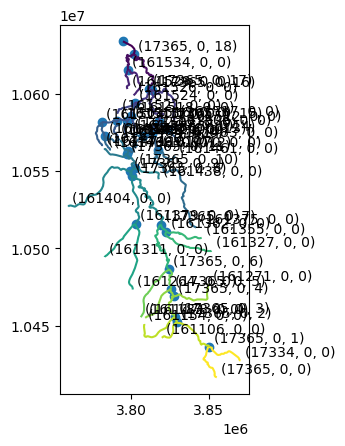

In [9]:
edges = shapefile_with_dist.query("estuary==60")
ax = edges.plot(column="distance_from_estuary")
nodes = network.topology.loc[shapefile_with_dist.query("estuary==60").downstream_node_id.unique()]
nodes.plot(ax=ax)


for x, y, label in zip(edges.geometry.apply(lambda x: x.coords[0][0]), edges.geometry.apply(lambda x: x.coords[0][1]), edges.index):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points")

#network.topology.query("estuary").clip_by_rect(*test.query("estuary==60").buffer(1).total_bounds.tolist()).plot(ax=ax)

In [19]:
edge_to_idx = {tuple(network.reachability["edge_ids"][i,:].tolist()): i for i in range(network.reachability["edge_ids"].shape[0])}

In [34]:
network.reachability["matrix"][edge_to_idx[(17365, 0, 0)],network.reachability["matrix"][edge_to_idx[(17365, 0, 0)],:].nonzero()].toarray()

array([], shape=(1, 0), dtype=float32)

In [31]:
network.reachability["matrix"][edge_to_idx[(17365, 0, 18)],network.reachability["matrix"][edge_to_idx[(17365, 0, 18)],:].nonzero()].toarray()

array([[116037., 116037.,  86271.,  82827.,  64903.,  59314.,  43310.,
         86271.,  82827.,  59314.,  43310.,  64903.,   6104.,   6104.]],
      dtype=float32)

In [32]:
network.reachability["matrix"][edge_to_idx[(17365, 0, 6)],network.reachability["matrix"][edge_to_idx[(17365, 0, 6)],:].nonzero()].toarray()

array([[116037., 116037.,  86271.,  82827.,  64903.,  59314.,  43310.,
         86271.,  82827.,  59314.,  43310.,  64903.,   6104.,   6104.]],
      dtype=float32)

In [54]:
edge_to_idx = {shapefile_with_dist.query("estuary==60").index[i]: i for i in range(shapefile_with_dist.query("estuary==60").shape[0])}

In [56]:
test[edge_to_idx[(17365, 0, 18)],test[edge_to_idx[(17365, 0, 18)],:].nonzero()].toarray()

array([[332343., 332343., 302577., 299133., 281209., 275620., 259616.,
        216306., 159430., 154069., 149819., 134458., 131927., 111160.,
        103854.,  87700.,  56350.,  53705.,  12463., 302577., 299133.,
        275620., 259616., 193834., 281209., 193834., 222410., 222410.,
        216306., 115707., 159430., 154069., 149819., 115707., 109578.,
        103854., 134458.,  99614.,  96144., 131927., 109578.,  89588.,
         82006.,  99614., 111160.,  78144.,  87700.,  96144.,  89588.,
         82006.,  78144.,  56350.,  68899.,  68899.,  53705.,  32887.,
         32887.,  12463.]])

In [55]:
test[edge_to_idx[(17365, 0, 6)],test[edge_to_idx[(17365, 0, 6)],:].nonzero()].toarray()

array([[116037., 116037.,  86271.,  82827.,  64903.,  59314.,  43310.,
         86271.,  82827.,  59314.,  43310.,  64903.,   6104.,   6104.]])

In [57]:
test[edge_to_idx[(17365, 0, 0)],test[edge_to_idx[(17365, 0, 0)],:].nonzero()].toarray()

array([], shape=(1, 0), dtype=float64)